# 拓展活动：寻找最优模型，并保存

In [1]:
import numpy as np  #数据库
import keras
import tensorflow as tf
#从keras库导入处理神经网络模型model所需的函数。
from keras.models import Sequential   #序贯模型
from keras.models import load_model 
#从keras库导入设计神经网络模型的各个层次layers需要用到的函数。
from keras.layers import Dense,Dropout,Activation,Flatten  #构建 keras网络结构
from keras.layers import Conv2D, MaxPooling2D
#从keras库导入神经网络模型的优化器
from keras.optimizers import SGD   #SGD随机梯度下降

%matplotlib inline
import cv2
import matplotlib.pyplot as plt    #画图

Using TensorFlow backend.
C:\Users\67897\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:526: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
C:\Users\67897\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:527: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
C:\Users\67897\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:528: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
C:\Users\67897\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py

In [2]:
#下面的函数get_nb_files（）功能是：获取指定目录directory下面的所有文件的总个数
import os
import glob
def get_nb_files(directory):
  """Get number of files by searching directory recursively"""
  if not os.path.exists(directory):
    return 0
  cnt = 0
  for r, dirs, files in os.walk(directory):
    for dr in dirs:
      cnt += len(glob.glob(os.path.join(r, dr + "/*")))
  return cnt

In [3]:
train_dir = 'mnist//train'
val_dir = 'mnist//test'
nb_train_samples = get_nb_files(train_dir)      # 训练样本个数
nb_val_samples = get_nb_files(val_dir)       #测试集样本个数
 
print('用于训练的样本总数nb_train_samples:',nb_train_samples,' 用于测试检验的样本总数nb_val_samples:',nb_val_samples)

#模型训练的参数,，跟输入图像的分类数目有关，跟图像的尺寸也有关。
# nb_classes= 10 #分类数，此行可以省略，因为下面一行会根据子文件夹的个数自动计算分类数。
nb_classes = len(glob.glob(train_dir + "/*"))   #我的分类总数，就是训练文件夹train和测试文件夹test下面的子文件夹的个数
print("分类数nb_classes:",nb_classes)
#IM_WIDTH, IM_HEIGHT = 299, 299  #若输入图像尺寸为28*28这种小图片，那么需要调小。
IM_WIDTH, IM_HEIGHT = 28, 28

batch_size = 512 #batch_size一般设置为总文件数的1%左右，如果太小，训练速度会很慢。
nb_epoch = 200

用于训练的样本总数nb_train_samples: 60000  用于测试检验的样本总数nb_val_samples: 10000
分类数nb_classes: 10


In [4]:
#数据准备：使用图片生成器ImageDataGenerator从原始数据生成更多数据
#　图片生成器ImageDataGenerator,通过拉伸，平移，旋转等使得数据量增大
from keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
     rescale = 1./255,#!!!此行最好不省略。下列4行的数据变换是否有，基本不会增加训练耗时
  
     rotation_range=20,  #图片随机转动的角度
     width_shift_range=0.2, #图片随机水平偏移的幅度
     height_shift_range=0.2, #图片随机竖直偏移的幅度
     fill_mode='nearest',  #当进行变换时超出边界的点将根据本参数给定的方法进行处理
     horizontal_flip=False) #适用于水平翻转不影响图片语义的时候

test_datagen = ImageDataGenerator(
     rescale = 1./255)  #!!!此行最好不省略。

# 从所给的原始的文件夹 生成训练数据train_generator与测试数据validation_generator
train_generator = train_datagen.flow_from_directory(
train_dir,  #原始的train文件夹
target_size=(IM_WIDTH, IM_HEIGHT),
batch_size=batch_size,
class_mode='categorical')
 
validation_generator = test_datagen.flow_from_directory(
val_dir,    #原始的test文件夹
target_size=(IM_WIDTH, IM_HEIGHT),
batch_size=batch_size,
class_mode='categorical')

Found 60000 images belonging to 10 classes.
Found 10000 images belonging to 10 classes.


In [5]:
#mnist的模型设计和训练
#从keras库导入设计神经网络模型的各个层次layers需要用到的函数。
from keras.layers import Dense,Dropout,Activation,Flatten  #构建 keras网络结构
from keras.layers import Conv2D, MaxPooling2D
model= Sequential() #创建一个序贯Sequential类型的模型，取名为model,接下来为model增加几层节点。

model.add(Conv2D(64,(3,3),input_shape = (28,28,3)))#卷积层
model.add(Activation('relu'))                         
model.add(MaxPooling2D(pool_size=(2,2)))#池化层
#以上3行的结构可以重复出现多次， Conv2D(参数可以改)，Activation('relu')，MaxPooling2D(参数可以改)
model.add(Conv2D(256,(3,3)))
model.add(Activation('relu'))
model.add(Flatten()) #快要结束前的一层Flatten()

model.add(Dropout(0.5))

model.add(Dense(256))  #放置在输出层之前，可以修改节点数目
model.add(Activation('relu'))

model.add(Dropout(0.5))

model.add(Dense(10)) #输出层
model.add(Activation('softmax'))

model.summary()
#编译模型方案1，优化器选rmsprop
# model.compile(optimizer='rmsprop',loss='categorical_crossentropy', metrics=['accuracy'])
#编译模型方案2，优化器选sgd
sgd = SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True) # 优化函数，设定学习率（lr）等参数
model.compile(optimizer=sgd,loss='categorical_crossentropy', metrics=['accuracy']) 
print("数据导入和预处理已经完成，模型设计完毕")

Instructions for updating:
Colocations handled automatically by placer.
Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 26, 26, 64)        1792      
_________________________________________________________________
activation_1 (Activation)    (None, 26, 26, 64)        0         
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 13, 13, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 11, 11, 256)       147712    
_________________________________________________________________
activation_2 (Activation)    (None, 11, 11, 256)       0         
_________________________________________________________________
flatten_1 (Flatten)  

In [6]:
'''
#MLP多层神经网络模型设计
model= Sequential() #创建一个序贯Sequential类型的模型，取名为model,接下来为model增加几层节点。
model.add(Dense(input_dim=784,units=784,activation='relu'))   #增加add输入层Dense，该层节点数目units为784
model.add(Dense(            units=50,activation='relu'))   #增加add隐藏层Dense，该层节点数目units为50
model.add(Dense(            units=10,activation='softmax'))
#model.summary()
#编译模型
sgd = SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True) # 优化函数，设定学习率（lr）等参数
model.compile(optimizer=sgd,loss='categorical_crossentropy', metrics=['accuracy']) 
print("数据导入和预处理已经完成，模型设计完毕")
'''

'\n#MLP多层神经网络模型设计\nmodel= Sequential() #创建一个序贯Sequential类型的模型，取名为model,接下来为model增加几层节点。\nmodel.add(Dense(input_dim=784,units=784,activation=\'relu\'))   #增加add输入层Dense，该层节点数目units为784\nmodel.add(Dense(            units=50,activation=\'relu\'))   #增加add隐藏层Dense，该层节点数目units为50\nmodel.add(Dense(            units=10,activation=\'softmax\'))\n#model.summary()\n#编译模型\nsgd = SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True) # 优化函数，设定学习率（lr）等参数\nmodel.compile(optimizer=sgd,loss=\'categorical_crossentropy\', metrics=[\'accuracy\']) \nprint("数据导入和预处理已经完成，模型设计完毕")\n'

# 训练200次，rescale = 1./255,不是featurewise_center=True,和featurewise_std_normalization=True。速度快很多。训练到136次的时候，耗时差不多8小时。准确率差不多到了99%。
![image.png](attachment:image.png)

In [7]:
#以下是模型训练的参数


import time 
t1 = time.strftime("%Y/%m/%d  %H:%M:%S")
print("模型训练开始时间starting time:",t1) ##24小时格式 
# 模型训练
history_ft = model.fit_generator(
train_generator,
steps_per_epoch=60000/batch_size,
nb_epoch=nb_epoch,
validation_data=validation_generator,
validation_steps=60000/batch_size,
class_weight='auto1',verbose=1) #verbose=2的意思：每个epoch没有时间戳？

模型训练开始时间starting time: 2021/12/05  22:22:08
Instructions for updating:
Use tf.cast instead.


C:\Users\67897\Anaconda3\lib\site-packages\ipykernel_launcher.py:14: UserWarning: The semantics of the Keras 2 argument `steps_per_epoch` is not the same as the Keras 1 argument `samples_per_epoch`. `steps_per_epoch` is the number of batches to draw from the generator at each epoch. Basically steps_per_epoch = samples_per_epoch/batch_size. Similarly `nb_val_samples`->`validation_steps` and `val_samples`->`steps` arguments have changed. Update your method calls accordingly.
  
C:\Users\67897\Anaconda3\lib\site-packages\ipykernel_launcher.py:14: UserWarning: Update your `fit_generator` call to the Keras 2 API: `fit_generator(<keras_pre..., steps_per_epoch=117.1875, validation_data=<keras_pre..., validation_steps=117.1875, class_weight="auto1", verbose=1, epochs=200)`
  


Epoch 1/200
118/117 [==============================] - 209s 2s/step - loss: 0.6574 - acc: 0.7938 - val_loss: 0.1949 - val_acc: 0.9413
Epoch 2/200
118/117 [==============================] - 210s 2s/step - loss: 0.2272 - acc: 0.9320 - val_loss: 0.1211 - val_acc: 0.9638
Epoch 3/200
118/117 [==============================] - 205s 2s/step - loss: 0.1651 - acc: 0.9506 - val_loss: 0.0903 - val_acc: 0.9710
Epoch 4/200
118/117 [==============================] - 204s 2s/step - loss: 0.1341 - acc: 0.9591 - val_loss: 0.0744 - val_acc: 0.9760
Epoch 5/200
118/117 [==============================] - 201s 2s/step - loss: 0.1148 - acc: 0.9653 - val_loss: 0.0694 - val_acc: 0.9772
Epoch 6/200
118/117 [==============================] - 202s 2s/step - loss: 0.1011 - acc: 0.9694 - val_loss: 0.0607 - val_acc: 0.9796
Epoch 7/200
118/117 [==============================] - 206s 2s/step - loss: 0.0906 - acc: 0.9724 - val_loss: 0.0540 - val_acc: 0.9821
Epoch 8/200
118/117 [==============================] - 201s 2s

Epoch 62/200
118/117 [==============================] - 202s 2s/step - loss: 0.0143 - acc: 0.9952 - val_loss: 0.0260 - val_acc: 0.9922
Epoch 63/200
118/117 [==============================] - 201s 2s/step - loss: 0.0139 - acc: 0.9954 - val_loss: 0.0250 - val_acc: 0.9913
Epoch 64/200
118/117 [==============================] - 202s 2s/step - loss: 0.0151 - acc: 0.9950 - val_loss: 0.0250 - val_acc: 0.9924
Epoch 65/200
118/117 [==============================] - 201s 2s/step - loss: 0.0138 - acc: 0.9955 - val_loss: 0.0255 - val_acc: 0.9921
Epoch 66/200
118/117 [==============================] - 202s 2s/step - loss: 0.0134 - acc: 0.9957 - val_loss: 0.0243 - val_acc: 0.9926
Epoch 67/200
118/117 [==============================] - 200s 2s/step - loss: 0.0133 - acc: 0.9956 - val_loss: 0.0254 - val_acc: 0.9911
Epoch 68/200
118/117 [==============================] - 201s 2s/step - loss: 0.0129 - acc: 0.9956 - val_loss: 0.0249 - val_acc: 0.9920
Epoch 69/200
118/117 [==============================] -

118/117 [==============================] - 214s 2s/step - loss: 0.0044 - acc: 0.9986 - val_loss: 0.0276 - val_acc: 0.9919
Epoch 183/200
118/117 [==============================] - 203s 2s/step - loss: 0.0038 - acc: 0.9989 - val_loss: 0.0261 - val_acc: 0.9926
Epoch 184/200
118/117 [==============================] - 205s 2s/step - loss: 0.0042 - acc: 0.9987 - val_loss: 0.0264 - val_acc: 0.9927
Epoch 185/200
118/117 [==============================] - 208s 2s/step - loss: 0.0037 - acc: 0.9988 - val_loss: 0.0270 - val_acc: 0.9924
Epoch 186/200
118/117 [==============================] - 208s 2s/step - loss: 0.0041 - acc: 0.9985 - val_loss: 0.0263 - val_acc: 0.9925
Epoch 187/200
118/117 [==============================] - 210s 2s/step - loss: 0.0042 - acc: 0.9987 - val_loss: 0.0266 - val_acc: 0.9932
Epoch 188/200
118/117 [==============================] - 210s 2s/step - loss: 0.0039 - acc: 0.9987 - val_loss: 0.0281 - val_acc: 0.9927
Epoch 189/200
118/117 [==============================] - 213s 

In [8]:
import time
t2 = time.strftime("%Y/%m/%d  %H:%M:%S")
print("模型训练开始和结束时间分别为 ：", t1, t2)
# 模型保存
# model.save("newModel1.h5",t2) 

模型训练开始和结束时间分别为 ： 2021/12/05  22:22:08 2021/12/06  09:51:33


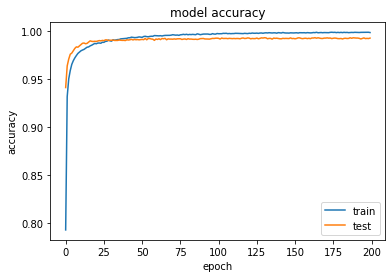

In [11]:
#acc
import matplotlib.pyplot as plt
plt.plot(history_ft.history['acc'])
plt.plot(history_ft.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='lower right')
plt.savefig('acc.jpg')

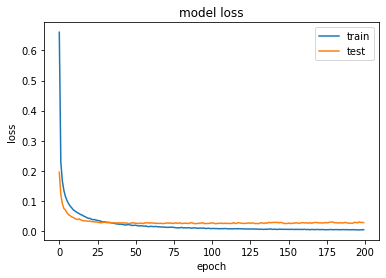

In [12]:
#loss
plt.plot(history_ft.history['loss'])
plt.plot(history_ft.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.savefig('loss.jpg')